# Wissenschaftliches Experiment: Performance-Analyse (Squirrel Secret Stash)
Dieses Notebook testet die Hypothesen H1 (Skalierung), H2 (Overhead) und H3 (Branch Prediction).
Wir vergleichen eine native Python `for`-Schleife (SISD) mit vektorisierten NumPy-Arrays (SIMD).

**Szenario:** Wir prüfen $n$ Nussverstecke. Wenn die Erdtiefe < 10 cm ist, berechnen wir 30% Verlust (Diebstahl/Frost).

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Wir testen verschiedene Datenmengen: von 10 (Small Data) bis 1 Million (Big Data)
data_sizes = [10, 100, 1_000, 10_000, 100_000, 1_000_000]

python_times = []
numpy_times = []

print("Starte Benchmark-Lauf...\n")

for n in data_sizes:
    # 1. Dummy-Daten generieren
    depths_np = np.random.uniform(1.0, 20.0, n)
    amounts_np = np.random.randint(10, 100, n)
    
    # Für einen fairen Vergleich konvertieren wir die Daten in native Python-Listen
    depths_list = depths_np.tolist()
    amounts_list = amounts_np.tolist()
    
    # -----------------------------------------------------
    # 2. Native Python Benchmark (for-Schleife / SISD)
    # -----------------------------------------------------
    start_py = time.perf_counter()
    python_loss = 0.0
    for i in range(n):
        if depths_list[i] < 10.0:  # Bedingte Logik (Branching)
            python_loss += amounts_list[i] * 0.3
    end_py = time.perf_counter()
    python_times.append(end_py - start_py)
    
    # -----------------------------------------------------
    # 3. NumPy Benchmark (Vektorisierung / SIMD)
    # -----------------------------------------------------
    start_np = time.perf_counter()
    # Maskierung ohne if/else (Branchless Programming)
    numpy_loss = np.sum(np.where(depths_np < 10.0, amounts_np * 0.3, 0))
    end_np = time.perf_counter()
    numpy_times.append(end_np - start_np)

print("Benchmark abgeschlossen! Erstelle Plot...")

Starte Benchmark-Lauf...

Benchmark abgeschlossen! Erstelle Plot...


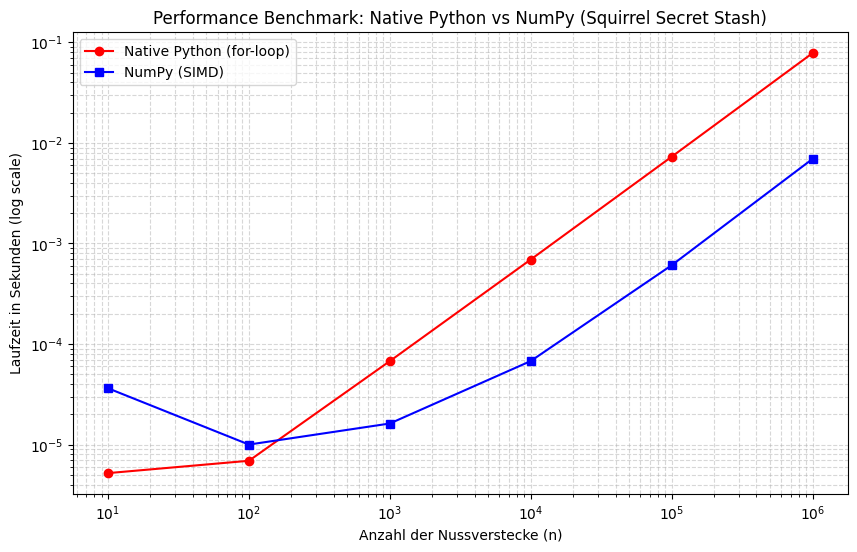

--- ERGEBNISSE FÜR n = 1.000.000 ---
Laufzeit Python: 0.0782 Sekunden
Laufzeit NumPy:  0.006939 Sekunden
Speedup-Faktor:  11.28x schneller!


In [2]:
# 4. Ergebnisse visualisieren (Plot)
plt.figure(figsize=(10, 6))
plt.plot(data_sizes, python_times, marker='o', color='red', label='Native Python (for-loop)')
plt.plot(data_sizes, numpy_times, marker='s', color='blue', label='NumPy (SIMD)')

# Beide Achsen logarithmisch, damit wir 10 und 1.000.000 im selben Chart gut sehen können
plt.xscale('log')
plt.yscale('log')

plt.title('Performance Benchmark: Native Python vs NumPy (Squirrel Secret Stash)')
plt.xlabel('Anzahl der Nussverstecke (n)')
plt.ylabel('Laufzeit in Sekunden (log scale)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Grafik anzeigen
plt.show()

# Ausgabe der finalen Zahlen für n = 1.000.000
speedup = python_times[-1] / numpy_times[-1]
print("--- ERGEBNISSE FÜR n = 1.000.000 ---")
print(f"Laufzeit Python: {python_times[-1]:.4f} Sekunden")
print(f"Laufzeit NumPy:  {numpy_times[-1]:.6f} Sekunden")
print(f"Speedup-Faktor:  {speedup:.2f}x schneller!")